# **Eurofood Corp – Sales Performance & Profitability Analysis** 

## **Business Problem**

**Eurofood Corp**, a global player in the food industry and retail distribution sector, aims to analyze its **sales performance** to better understand underlying **commercial dynamics** and optimize **strategic and operational decision-making**.

In a **data-driven decision-making context**, the sales and marketing teams are seeking to identify:

- **Financial performance** across **customers, products, and product categories**
- The effectiveness of the **loyalty program** (**Members vs Non-Members**) on purchase frequency and customer retention
- The **revenue concentration** and the contribution of **high-value products**
- **Temporal consumption trends** to improve **demand forecasting**, **inventory management**, and **promotional campaign planning**

> The ultimate objective is to deliver **reliable, standardized, and actionable KPIs** to support **strategic decision-making at all levels of the organization (operations, marketing, and executive management)**.

---

## **Data Context & Scope**

The dataset consists of **structured transactional data**, representing **customer purchases over multiple time periods and market segments**, within a simulated **enterprise sales environment (Eurofood Corp)**.

**The data has been anonymized and slightly modified to ensure confidentiality while simulating a realistic business environment. However, it remains representative of typical behaviors observed in the retail distribution sector. As such, results should be interpreted as analytical indicators rather than exact production-grade measurements.**

This dataset enables the exploration of key business questions such as **product performance analysis**, **customer segmentation**, and **sales profitability assessment**.

> The overall work is framed within a **realistic analytical environment**, designed to replicate the practices of a data team in a corporate setting while maintaining an exploratory and learning-oriented approach.

---

## **Objective**

- Generate **reliable, standardized, and actionable KPIs**
- Identify the main **drivers of commercial performance**
- Understand **revenue structure and concentration patterns**
- Segment **customers and products** to enhance decision-making
- Deliver actionable insights for **sales, marketing, and executive teams**

## **Table of Contents (TOC)**

- [1. Methodology](#1-methodology)
- [2. Library Imports](#2-library-imports)
- [3. CSV Data Loading](#3-csv-data-loading)
- [4. Separator Function & Quick Validation](#4-separator-function--quick-validation)
- [5. Dataset Overview](#5-dataset-overview)
- [6. Initial Descriptive Statistics](#6-initial-descriptive-statistics)
- [7. Dataset Shape Check](#7-dataset-shape-verification)
- [8. Data Preparation & Type Conversions](#8-data-preparation--type-conversions)
- [9. Missing Values Assessment](#9-missing-value-assessment)
- [10. Missing Values Treatment](#10-missing-value-handling)
- [11. Post-Cleaning Descriptive Analysis](#11-post-cleaning-descriptive-analysis)
- [12. Outlier Management](#12-outlier-management)
- [13. Global Data Preparation & Feature Engineering](#13-global-data-preparation--feature-engineering)
  - [13.1 Derived Feature Engineering](#131-feature-engineering-derived-variables)
  - [13.2 Temporal Feature Engineering](#132-dataset-merging-for-kpi-construction) 
  - [13.3 Customer Data Merging & Segment Dataset Preparation](#13.3-customer-data-merge-and-segment-dataset-preparation)
  - [13.4 Product Data Merging](#13.4-product-data-merge) 
- [14. KPI Analysis](#kpianalysis)
  - [14.1 KPI by Gender](#141-kpis-by-gender)
  - [14.2 KPI by Customer Status](#142-kpi-custumer)  
  - [14.3 KPI by Product Category](#143-kpi-by-product-category)
  - [14.4 Monthly Time-Based KPI](#144-monthly-temporal-kpi)
- [15. Data Visualization & Insights](#15-data-visualization--insights)
  - [15.1 Revenue Distribution by Gender](#151-revenue-distribution-by-gender)
  - [15.2 Monthly Revenue Trend by Customer Status](#152-monthly-revenue-trend-by-customer-status)
  - [15.3 Total Revenue by Category](#153-total-revenue-by-category)
  - [15.4 Top 10 Products by Revenue](#154-top-10-products-by-revenue)
  - [15.5 Revenue, Profit & Margin Heatmap by Category](#155-revenue-profit--margin-heatmap-by-category)
  - [15.6 Revenue vs Margin Scatter Plot (Customer Level)](#156-revenue-vs-margin-scatter-plot-customer-level)
  - [15.7 Average Revenue by Day of Week](#157-average-revenue-by-day-of-week)
- [16. Customer Value Segmentation & Revenue Concentration Analysis](#16-customer-lifetime-value--pareto-analysis) 
  - [16.1.1 Customer Lifetime Value (CLV)](#1611-customer-lifetime-value-clv)
  - [16.1.2 Customer Revenue Distribution](#1612-customer-revenue-distribution)
  - [16.2 Pareto Analysis – Product Revenue Contribution](#163-pareto-analysis--product-revenue-contribution)
- [17. Cleaned Datasets Export](#17-cleaned-datasets-export)
- [18. Executive Conclusion](#18-executive-conclusion)

## 1. Methodology <a id="1-methodology"></a>

The notebook follows the **CRISP-DM framework (Cross-Industry Standard Process for Data Mining)**:

1. **Data Acquisition (Obtain)**: loading and initial exploration of the Sales, Products, and Customers datasets.
2. **Data Preparation (Scrub)**: handling missing values, data type conversions, and outlier treatment.
3. **Exploratory Data Analysis (Explore)**: descriptive statistics, KPI generation, and data visualization.
4. **Feature Engineering & Modeling (Model)**: derived metrics computation and segmentation by Gender, Customer Status, and Product Category.
5. **Insight Generation (Interpret)**: business insights extraction and strategic recommendations.

Each stage is documented to highlight both the **business reasoning and technical approach** behind the analysis.

## 2. Library Imports <a id="2-library-imports"></a>

In [1]:
import pandas as pd
import numpy as np
import random
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, HTML
from io import StringIO
import shutil

sns.set_theme(style="ticks")

## 3. CSV File Loading <a id="3-csv-file-loading"></a>

In [2]:
sales = pd.read_csv("Sales_Eurofood_Corp.csv")
products = pd.read_csv("Products_Eurofood_Corp.csv")
customers = pd.read_csv("Customers_Eurofood_Corp.csv")

## 4. Creation of a Separator Function <a id="4-fonction-de-separation"></a>

- Improve notebook readability and ensure correct dataset import and validation.

In [3]:
width = shutil.get_terminal_size().columns

def separator():
    print('-' * width) # Displays a full-width visual separator

In [4]:
# Creation of the HTML container for dataset previews
html_preview_content = "<div style='display:flex; gap:20px; overflow-x:auto;'>"

# List of datasets to be displayed
datasets_preview = {
    "Sales": sales,
    "Products": products,
    "Customers": customers
}

# Iteration over each dataset
for name, df in datasets_preview.items():
    # Extraction of the first 5 rows 
    head_html = df.head().to_html(index=False)

    # Construction of a visual card for each dataset
    html_preview_content += f"""
    <div style='min-width:350px; max-width:350px; border:1px solid #ccc;
                padding:10px; border-radius:8px;'>
        <h4 style='text-align:center;'>{name} dataset</h4>
        <div style='overflow-x:auto;'>{head_html}</div>
    </div>
    """

html_preview_content += "</div>"

# Final output
display(HTML(html_preview_content))

## 5. Dataset Overview <a id="5-dataset-overview"></a>

- Quick overview of the first rows to understand dataset structure.
- Check of key columns across each dataset.
- Inspection of data types and detection of missing values or anomalies.

In [5]:
# Creation of the HTML container for dataset information
html_info_content = "<div style='display:flex; gap:20px; overflow-x:auto;'>"

# List of datasets
datasets_info = {
    "Sales": sales,
    "Products": products,
    "Customers": customers
}

# Iteration over each dataset
for name, df in datasets_info.items():
    # Capture of the output from df.info() into a string buffer
    buffer = StringIO()
    df.info(buf=buffer)
    info_text = buffer.getvalue().replace("\n", "<br>")  # HTML conversion

    
    html_info_content += f"""
    <div style='min-width:350px; max-width:350px; border:1px solid #ccc;
                padding:10px; border-radius:8px;'>
        <h4 style='text-align:center;'>{name} dataset info</h4>
        <div style='font-size:12px; overflow-x:auto;'>{info_text}</div>
    </div>
    """

html_info_content += "</div>"

# Final output
display(HTML(html_info_content))

- **Sales**: 1,000 transactions, with minor missing values in **Revenue** and **Profit** (~5%). The **TransactionDate** field requires conversion to datetime format for temporal analysis.
- **Products**: 50 products, fully complete dataset, ready for downstream merging and analysis.
- **Customers**: 100 customers, with partially missing **Gender** information (52/100 available), requiring treatment for gender-based segmentation analysis.

## 6. Initial Descriptive Statistics <a id="6-initial-descriptive-statistics"></a>

- Statistical summary of numerical columns to identify outliers and distribution patterns.

In [6]:
html_stats_content = "<div style='display:flex; gap:20px; overflow-x:auto;'>"

datasets_stats = {
    "Sales": sales,
    "Products": products,
    "Customers": customers
}

for name, df in datasets_stats.items():
    # Selection of numerical columns only
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    if len(numeric_cols) > 0:
        desc_html = df[numeric_cols].describe().round(2).to_html()
    else:
        desc_html = "<p>No relevant statistical output identified</p>"

    # HTML
    html_stats_content += f"""
    <div style='min-width:350px; max-width:350px; border:1px solid #ccc;
                padding:10px; border-radius:8px;'>
        <h4 style='text-align:center;'>{name} dataset descriptive stats</h4>
        <div style='overflow-x:auto;'>{desc_html}</div>
    </div>
    """

html_stats_content += "</div>"

# Final output
display(HTML(html_stats_content))

- Presence of **extreme values** in **Revenue** and **Profit**, requiring appropriate treatment to ensure reliable analysis results.

## 7. Dataset Shape Check<a id="7-dataset-shape-verification"></a>

- Quick validation of the number of rows and columns for each dataset.
- Ensures structural consistency across datasets prior to data cleaning.

In [7]:
print("Customers dataset shape")
print(customers.shape)
separator()

print("Products dataset shape")
print(products.shape)
separator()

print("Sales dataset shape")
print(sales.shape)
separator()

Customers dataset shape
(100, 4)
--------------------------------------------------------------------------------
Products dataset shape
(50, 4)
--------------------------------------------------------------------------------
Sales dataset shape
(1000, 6)
--------------------------------------------------------------------------------


## 8. Data Preparation & Type Conversions <a id="8-data-preparation--type-conversions"></a>

- Creation of dataset copies to preserve raw data integrity.
- Conversion of **TransactionDate** into datetime format for time-series analysis.
- Transformation of categorical features into **category** type to optimize memory usage and processing efficiency.

In [8]:
# -------------------------------
# Dataset copies to preserve raw data integrity
# -------------------------------
sales_clean = sales.copy()
customers_clean = customers.copy()
products_clean = products.copy()

# -------------------------------
# Date conversion process
# -------------------------------
sales_clean["TransactionDate"] = pd.to_datetime(sales_clean["TransactionDate"])

# -------------------------------
# Categorical features handling
# -------------------------------
customers_clean["CustomerStatus"] = customers_clean["CustomerStatus"].astype("category")
customers_clean["Gender"] = customers_clean["Gender"].astype("category")
products_clean["Category"] = products_clean["Category"].astype("category")

# -------------------------------
# Simplified check
# -------------------------------
print("Copies and data type conversions successfully applied across all datasets..")

Copies and data type conversions successfully applied across all datasets..


## 9. Missing Values Assessment <a id="9-missing-value-assessment"></a>

- Identification of missing values that could impact financial analysis and KPI reliability.
- Preparation for data cleaning prior to KPI computation.

In [9]:
print("Sales missing values:")
print(sales_clean.isna().sum())
separator()

print("Customers missing values:")
print(customers_clean.isna().sum())
separator()

print("Products missing values:")
print(products_clean.isna().sum())
separator()

# Duplicate records check
print("Sales duplicates:", sales_clean.duplicated().sum())
print("Customers duplicates:", customers_clean.duplicated().sum())
print("Products duplicates:", products_clean.duplicated().sum())
separator()

Sales missing values:
TransactionID       0
CustomerID          0
ProductID           0
Revenue            50
Profit             50
TransactionDate     0
dtype: int64
--------------------------------------------------------------------------------
Customers missing values:
CustomerID         0
CustomerStatus     0
CustomerName       0
Gender            48
dtype: int64
--------------------------------------------------------------------------------
Products missing values:
ProductID      0
ProductName    0
Category       0
Price          0
dtype: int64
--------------------------------------------------------------------------------
Sales duplicates: 0
Customers duplicates: 0
Products duplicates: 0
--------------------------------------------------------------------------------


- Missing values in **Revenue** and **Profit**, potentially impacting financial KPIs reliability.
- Missing values in **Gender** for non-member customers (structural data gap).
- Data treatment will be applied prior to KPI computation to ensure analytical robustness and result reliability.

## 10. Missing Values Treatment <a id="10-missing-value-handling"></a>

- Ensuring analytical reliability by handling missing values prior to downstream analysis.

In [10]:
# Imputation of missing values in Gender
customers_clean["Gender"] = customers_clean["Gender"].cat.add_categories("Unknown")
customers_clean["Gender"] = customers_clean["Gender"].fillna("Unknown")

# Removal of transactions with missing Revenue or Profit
sales_clean = sales_clean.dropna(subset=["Revenue", "Profit"])

# Final check
print("Sales missing values:")
print(sales_clean.isna().sum())
separator()

print("Customers missing values:")
print(customers_clean.isna().sum())
separator()

print("Products missing values:")
print(products_clean.isna().sum())
separator()

print("Number of transactions after cleaning :", len(sales_clean))
separator()

Sales missing values:
TransactionID      0
CustomerID         0
ProductID          0
Revenue            0
Profit             0
TransactionDate    0
dtype: int64
--------------------------------------------------------------------------------
Customers missing values:
CustomerID        0
CustomerStatus    0
CustomerName      0
Gender            0
dtype: int64
--------------------------------------------------------------------------------
Products missing values:
ProductID      0
ProductName    0
Category       0
Price          0
dtype: int64
--------------------------------------------------------------------------------
Number of transactions after cleaning : 902
--------------------------------------------------------------------------------


- Missing values in **Gender** were imputed with "Unknown" to ensure a fully non-null dataset while preserving the information of absence as a meaningful category.
- Transactions with missing **Revenue** or **Profit** were removed, as these variables are critical for financial analysis and their absence makes the transaction non-exploitable for KPI computation.
- The removal accounts for approximately 5% of the dataset, which remains acceptable and ensures KPI reliability based on valid transactional data only.

## 11. Post-Cleaning Descriptive Analysis <a id="11-post-cleaning-descriptive-analysis"></a>

- Validation of data distributions after cleaning and preparation for derived metric computation.

In [11]:
# Updated descriptive analysis after data cleaning to ensure reliable statistical insights
numeric_cols = ["Revenue", "Profit"]

print("Sales dataset - descriptive statistics")
print(sales_clean[numeric_cols].describe().round(2))
separator()

Sales dataset - descriptive statistics
       Revenue  Profit
count   902.00  902.00
mean    106.54   16.65
std     127.86   35.55
min       1.05 -153.10
25%      48.83   -2.57
50%      97.72   14.10
75%     147.43   32.50
max    1899.20  484.50
--------------------------------------------------------------------------------


- **Revenue** and **Profit** show extreme values (high min/max range and standard deviation), indicating the presence of outliers that need to be addressed.
- Identifiers (**TransactionID**, **CustomerID**, **ProductID**) are complete and consistent across the dataset.
- These observations support the preparation of **Margin** and **CumulativeRevenue** computations.

## 12. Outlier Management <a id="12-outlier-management"></a>

- Identification of extreme values in **Revenue** and **Profit** to assess and document their potential impact on analysis.
- To avoid bias in statistical measures, outliers are detected using the **IQR (Interquartile Range) method**, enabling early identification prior to selecting an appropriate treatment strategy.

In [12]:
def detect_outliers_IQR(df, column):
    """
    Detect outliers in a column using the IQR method
    Retourne le DataFrame filtré contenant uniquement les outliers.
    """
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    outliers = df[(df[column] < Q1 - 1.5*IQR) | (df[column] > Q3 + 1.5*IQR)]
    return outliers

# Applied to Revenue and Profit
outliers_revenue = detect_outliers_IQR(sales_clean, "Revenue")
outliers_profit = detect_outliers_IQR(sales_clean, "Profit")

# Number of outliers
print("Number of Revenue outliers :", len(outliers_revenue))
separator()

print("Number of Profit outliers :", len(outliers_profit))
separator()

Number of Revenue outliers : 7
--------------------------------------------------------------------------------
Number of Profit outliers : 7
--------------------------------------------------------------------------------


- **Revenue** and **Profit** exhibit extreme values identified using the **IQR method**.
- These outliers are documented to highlight data variability and assess their impact on financial analysis.
- For specific KPI, these values may be temporarily excluded to prevent distortion of results, while the full dataset is preserved for transparency.
- Outlier analysis is conducted on **sales_clean**, as these are the critical financial variables for performance evaluation.

## 13. Global Data Preparation & Feature Engineering <a id="13-global-data-preparation--feature-engineering"></a>

### 13.1 Derived Feature Engineering <a id="131-feature-engineering-derived-variables"></a>

- Computation of key derived features for analysis, including **Margin** and **CumulativeRevenue** at both customer and product levels.

In [13]:
# Transaction-level Margin
sales_clean["Margin"] = sales_clean["Revenue"] - sales_clean["Profit"]

# Cumulative Revenue per customer
sales_clean = sales_clean.sort_values(["CustomerID", "TransactionDate"])
sales_clean["CumulativeRevenue_Client"] = sales_clean.groupby("CustomerID")["Revenue"].cumsum()

# Cumulative Revenue per product
sales_clean["CumulativeRevenue_Product"] = sales_clean.groupby("ProductID")["Revenue"].cumsum()

### 13.2 Temporal Feature Engineering <a id="132-dataset-merging-for-kpi-construction"></a>

- Creation of temporal features to enable monthly analysis and day-of-week performance tracking.

In [14]:
# Temporal features
sales_clean["YearMonth"] = sales_clean["TransactionDate"].dt.to_period("M")
sales_clean["Weekday"] = sales_clean["TransactionDate"].dt.day_name()

### 13.3 Customer Data Merging & Segment Dataset Preparation <a id="13.3-customer-data-merge-and-segment-dataset-preparation"></a>

- Merging sales data with customer information to build segment-specific datasets by Gender and Customer Status.

In [17]:
# Merging with customers_clean to prepare multiple analytical datasets
sales_customers = sales_clean.merge(customers_clean, on="CustomerID", how="left")

# Dataset for KPIs and visualizations by Gender (excluding "Unknown")
sales_gender = sales_customers[sales_customers["Gender"] != "Unknown"].copy()
if sales_gender["Gender"].dtype.name == "category":
    sales_gender["Gender"] = sales_gender["Gender"].cat.remove_unused_categories()

# Dataset for KPIs and visualizations by Customer Status
sales_status = sales_customers.copy()

### 13.4 Product Data Merging <a id="13.4-product-data-merge"></a>

- Merging sales data with product information to prepare datasets segmented by **Category** and **Product**.

In [18]:
# Merging with products_clean for KPI and visualizations by Category or Product
sales_products = sales_clean.merge(products_clean, on="ProductID", how="left")

## 14. KPI Analysis <a id="kpianalysis"></a>

### 14.1 KPI by Gender <a id="14.1-kpi-gender"></a>

- Computation of financial KPI segmented by **Gender** to identify behavioral differences across customer groups.

In [19]:
# --------------------- KPI by Gender ---------------------
kpi_gender_summary = sales_gender.groupby("Gender", observed=True).agg({
    "Revenue": ["sum", "mean", "max"],
    "Profit": ["sum", "mean", "max"],
    "Margin": ["sum", "mean", "max"]
}).reset_index()

# Column renaming for clarity
kpi_gender_summary.columns = ["Gender", "Revenue_sum", "Revenue_mean", "Revenue_max",
                              "Profit_sum", "Profit_mean", "Profit_max",
                              "Margin_sum", "Margin_mean", "Margin_max"]

print("KPI by Gender")
print(kpi_gender_summary.head().round(2))

KPI by Gender
   Gender  Revenue_sum  Revenue_mean  Revenue_max  Profit_sum  Profit_mean  \
0  Female     25063.20        114.97       1449.9     3514.36        16.12   
1    Male     26799.42         99.63       1519.1     3855.79        14.33   

   Profit_max  Margin_sum  Margin_mean  Margin_max  
0       399.5    21548.84        98.85     1433.80  
1        64.1    22943.63        85.29     1525.41  


**KPI by Gender**  
- **Female customers** exhibit higher average revenue and higher average margin, while **male customers** show higher peak values in both **Revenue_max** and **Margin_max**, indicating larger one-off transactions.  
- This suggests that female customers tend to purchase more consistently, whereas male customers are more associated with occasional high-value purchases.

### 14.2 KPI by Customer Status <a id="142-kpi-custumer"></a>
- Analyze financial KPIs by customer status to assess the profitability of the loyalty program.  

In [20]:
# --------------------- KPI by Customer Status ---------------------
kpi_status_summary = sales_status.groupby("CustomerStatus", observed=True).agg({
    "Revenue": ["sum", "mean", "max"],
    "Profit": ["sum", "mean", "max"],
    "Margin": ["sum", "mean", "max"]
}).reset_index()

kpi_status_summary.columns = ["CustomerStatus", "Revenue_sum", "Revenue_mean", "Revenue_max",
                              "Profit_sum", "Profit_mean", "Profit_max",
                              "Margin_sum", "Margin_mean", "Margin_max"]

print("KPI by Customer Status")
print(kpi_status_summary.head().round(2))

KPI by Customer Status
  CustomerStatus  Revenue_sum  Revenue_mean  Revenue_max  Profit_sum  \
0         Member     51862.62        106.49       1519.1     7370.15   
1     Non-Member     44238.21        106.60       1899.2     7643.84   

   Profit_mean  Profit_max  Margin_sum  Margin_mean  Margin_max  
0        15.13       399.5    44492.47        91.36     1525.41  
1        18.42       484.5    36594.37        88.18     1899.28  


**KPI by Customer Status** 
- **Members** generate higher **total revenue and margin**, despite a slightly lower number of customers (48 vs 52), indicating more consistent and higher-value purchasing behavior.  
- Confirms that the **loyalty program is profitable**.  

### 14.3 KPI by Product Category <a id="143-kpi-by-product-category"></a>
- Analyze financial KPIs by product category to identify the most profitable categories.

In [21]:
# --------------------- KPI by Product Category ---------------------
kpi_category_summary = sales_products.groupby("Category", observed=True).agg({
    "Revenue": ["sum", "mean", "max"],
    "Profit": ["sum", "mean", "max"],
    "Margin": ["sum", "mean", "max"]
}).reset_index()

kpi_category_summary.columns = ["Category", "Revenue_sum", "Revenue_mean", "Revenue_max",
                                "Profit_sum", "Profit_mean", "Profit_max",
                                "Margin_sum", "Margin_mean", "Margin_max"]

print("KPI by Category")
print(kpi_category_summary.head().round(2))

KPI by Category
    Category  Revenue_sum  Revenue_mean  Revenue_max  Profit_sum  Profit_mean  \
0     Bakery     14358.17        104.80      1899.20     2224.50        16.24   
1  Beverages     22248.06        119.61      1519.10     3176.60        17.08   
2      Dairy     14933.03        102.99      1362.50     2012.29        13.88   
3     Frozen      5740.00        102.50       189.63      719.46        12.85   
4     Fruits      9430.50        125.74      1826.60     1390.68        18.54   

   Profit_max  Margin_sum  Margin_mean  Margin_max  
0      248.70    12133.67        88.57     1899.28  
1      484.50    19071.46       102.53     1525.41  
2       49.20    12920.74        89.11     1370.71  
3       49.18     5020.54        89.65      189.49  
4      213.10     8039.82       107.20     1845.92  


**KPI by Category** 
- **Beverages and Fruits** have the **highest average revenue and average margin**, while some transactions in **Bakery** or **Fruits** can be exceptionally large.

### 14.4 Monthly Time-Based KPI <a id="144-monthly-temporal-kpi"></a> 
- Analyze financial KPIs on a monthly basis to identify trends and seasonality.

In [22]:
# --------------------- Monthly Time-Based KPI ---------------------
kpi_time = sales_clean.groupby("YearMonth", observed=True).agg({
    "Revenue": ["sum", "mean"],
    "Profit": ["sum", "mean"],
    "Margin": ["sum", "mean"]
}).reset_index()

kpi_time.columns = ["YearMonth", "Revenue_sum", "Revenue_mean",
                    "Profit_sum", "Profit_mean", "Margin_sum", "Margin_mean"]

print("Monthly Time-Based KPI")
print(kpi_time.head().round(2))

Monthly Time-Based KPI
  YearMonth  Revenue_sum  Revenue_mean  Profit_sum  Profit_mean  Margin_sum  \
0   2018-01      1205.68        120.57      115.09        11.51     1090.59   
1   2018-02      1449.72         90.61      337.53        21.10     1112.19   
2   2018-03       948.96        135.57       37.30         5.33      911.66   
3   2018-04       320.29         53.38       46.82         7.80      273.47   
4   2018-05      1102.32         84.79      282.15        21.70      820.17   

   Margin_mean  
0       109.06  
1        69.51  
2       130.24  
3        45.58  
4        63.09  


**Monthly Time-Based KPI** 
- Revenue and margin **vary significantly** from month to month, with peaks (e.g., March) and dips (e.g., April), highlighting sales seasonality and the importance of **stock planning and promotional strategy**

## 15. Data Visualization & Insights <a id="15-data-visualization--insights"></a> 

### 15.1 Revenue Distribution by Gender <a id="151-revenue-distribution-by-gender"></a> 
- Visualize revenue distribution by gender to identify underlying trends.

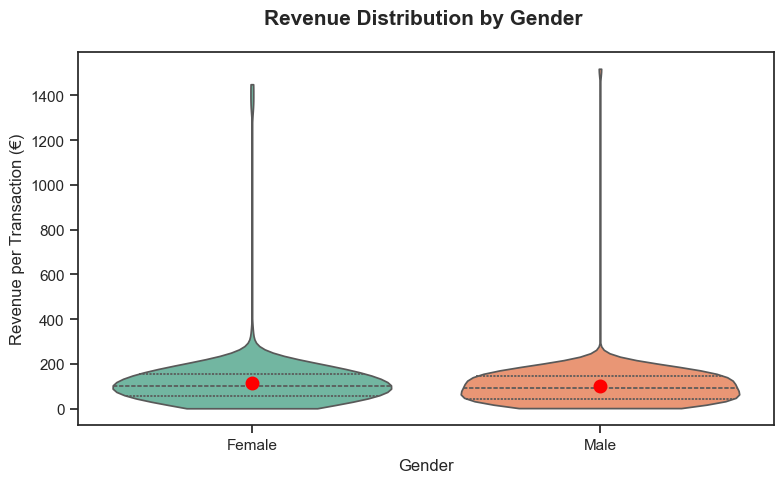

In [23]:
# --------------------- Revenue Distribution by Gender ---------------------
plt.figure(figsize=(8,5))
sns.violinplot(
    data=sales_gender,
    x="Gender",
    y="Revenue",
    hue="Gender",
    palette="Set2",
    inner="quartile",
    cut=0,
    legend=False
)
# Average shown as red dot 
sns.pointplot(
    data=sales_gender,
    x="Gender",
    y="Revenue",
    estimator="mean",
    errorbar=None,
    color="red",
    markers="o",
    linestyles="",
    markersize=8
)
plt.title(
    "Revenue Distribution by Gender ",
    fontsize=15,
    weight="bold",
    pad=20
)
plt.xlabel("Gender", fontsize=12)
plt.ylabel("Revenue per Transaction (€)", fontsize=12)
plt.tight_layout()
plt.show()

 - Average revenues are **similar** for both *Female* and *Male*, with significant **outliers** that should be taken into account in financial analysis.

### 15.2 Monthly Revenue Trend by Customer Status <a id="152-monthly-revenue-trend-by-customer-status"></a> 
- Track monthly revenue by customer status to observe customer loyalty and seasonal variations.

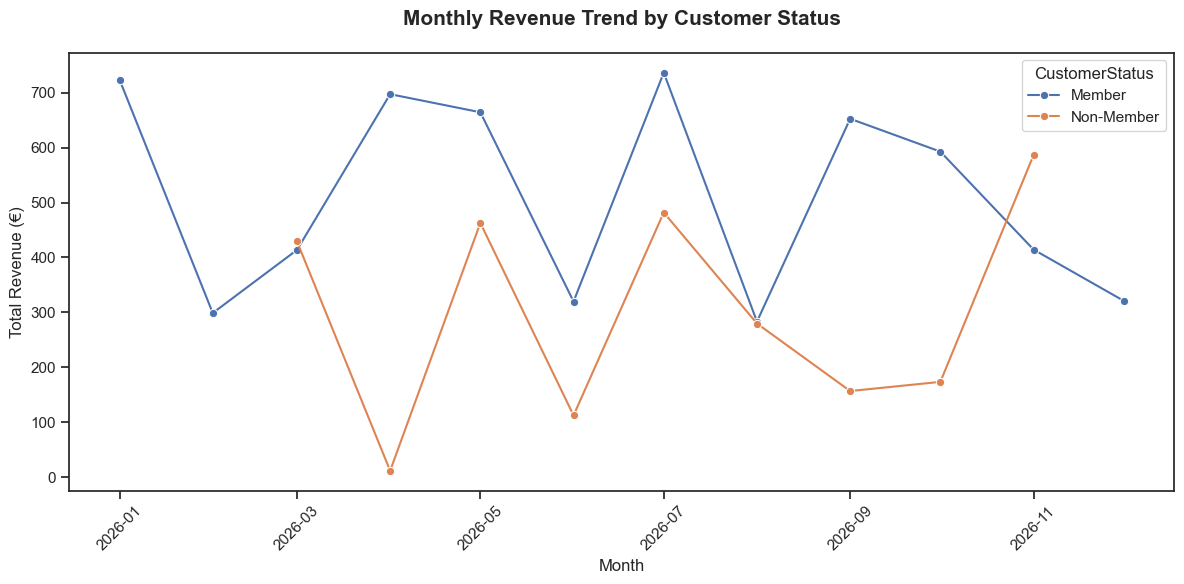

In [24]:
# --------------------- Monthly Revenue Trend by Customer Status ---------------------

monthly_revenue = (
    sales_status
    .groupby(
        [sales_status["TransactionDate"].dt.to_period("M"), "CustomerStatus"],
        observed=True
    )["Revenue"]
    .sum()
    .reset_index()
)
monthly_revenue["TransactionDate"] = monthly_revenue["TransactionDate"].dt.to_timestamp()

last_12 = monthly_revenue["TransactionDate"].sort_values().unique()[-12:]
monthly_revenue = monthly_revenue[
    monthly_revenue["TransactionDate"].isin(last_12)
]

plt.figure(figsize=(12,6))
sns.lineplot(
    data=monthly_revenue,
    x="TransactionDate",
    y="Revenue",
    hue="CustomerStatus",
    marker="o"
)
plt.title(
    "Monthly Revenue Trend by Customer Status",
    fontsize=15,
    weight="bold",
    pad=20
)
plt.xlabel("Month", fontsize=12)
plt.ylabel("Total Revenue (€)", fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

- *Members* show **regular peaks** throughout the year, indicating **stable customer loyalty**.  
- *Non-Members* exhibit a more volatile pattern, with a strong **year-end peak**, likely driven by a **promotion or seasonal effect**.

### 15.3 Total Revenue by Category <a id="153-total-revenue-by-category"></a> 
- Analyze total revenue by category to identify the best-performing product categories.

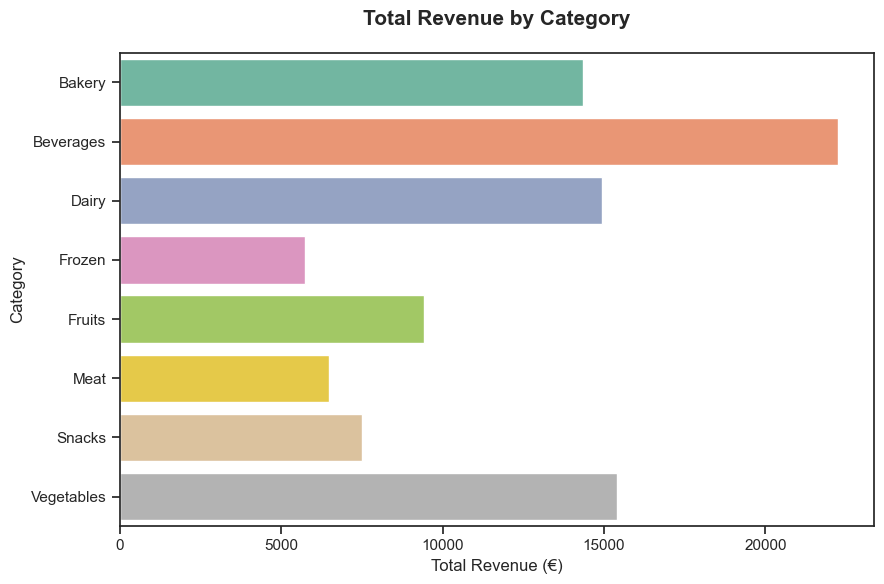

In [25]:
# --------------------- Total Revenue by Category ---------------------
category_revenue = (
    sales_products
    .groupby("Category", observed=True)["Revenue"]
    .sum()
    .sort_values(ascending=False)
    .round(1)
)

plt.figure(figsize=(9,6))
sns.barplot(
    x=category_revenue.values,
    y=category_revenue.index,
    hue=category_revenue.index,
    palette="Set2",
    legend=False
)
plt.title(
    "Total Revenue by Category",
    fontsize=15,
    weight="bold",
    pad=20
)
plt.xlabel("Total Revenue (€)", fontsize=12)
plt.ylabel("Category", fontsize=12)
plt.tight_layout()
plt.show()

- **Beverages** clearly dominates, followed by **Vegetables** and **Dairy**.  
- The horizontal visualization makes comparisons easier and highlights low-revenue categories that could be optimized.

### 15.4 Top 10 Products by Revenue <a id="154-top-10-products-by-revenue"></a> 
- Identify the products generating the highest revenue.

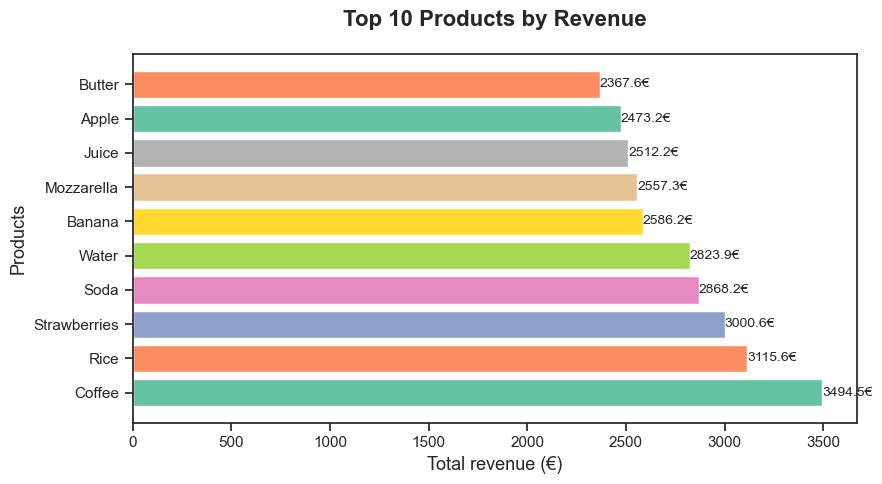

In [26]:
# --------------------- Top 10 Products by Revenue ---------------------
top_products = sales_products.groupby("ProductName", observed=True)["Revenue"].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(9,5))
plt.barh(top_products.index, top_products.values, color=sns.color_palette("Set2", len(top_products)))
plt.xlabel("Total revenue (€)", fontsize=13)
plt.ylabel("Products", fontsize=13)
plt.title("Top 10 Products by Revenue", fontsize=16, weight="bold", pad=20)
for i, v in enumerate(top_products.values):
    plt.text(v + 0.5, i, f"{v:.1f}€", va='center', fontsize=10)
plt.tight_layout()
plt.show()

- **"Coffee"** clearly dominates revenue.  
- Performance is distributed across multiple products, reducing dependency on a single item.  
- **High-turnover products** are the main revenue driver.

### 15.5 Revenue, Profit & Margin Heatmap by Category <a id="155-revenue-profit--margin-heatmap-by-category"></a>      
- Compare financial KPIs across categories to highlight the best-performing segments. 

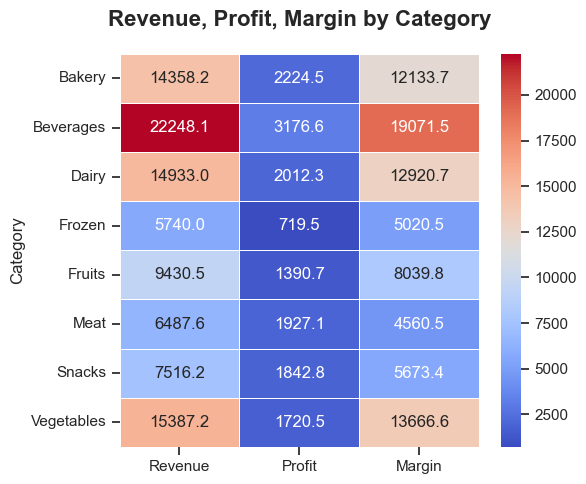

In [27]:
# --------------------- Heatmap Revenue, Profit, Margin by Category  ---------------------
category_summary = sales_products.groupby("Category", observed=True)[["Revenue","Profit","Margin"]].sum()

plt.figure(figsize=(6,5))
sns.heatmap(
    category_summary,
    annot=True,
    fmt=".1f",
    cmap="coolwarm",
    linewidths=0.5
)
plt.title(
    "Revenue, Profit, Margin by Category",
    fontsize=16,
    weight="bold",
    pad=20
)
plt.tight_layout()
plt.show()

- **Beverages** is the best-performing category in terms of both revenue and margin. **Frozen** remains underperforming.  
- **Profitability is consistent with volume**, with a clear leadership from beverages.

### 15.6 Revenue vs Margin Scatter Plot <a id="156-revenue-vs-margin-scatter-plot-customer-level"></a>   
- Identify the relationship between revenue and margin at the customer level, with point size representing the number of transactions.

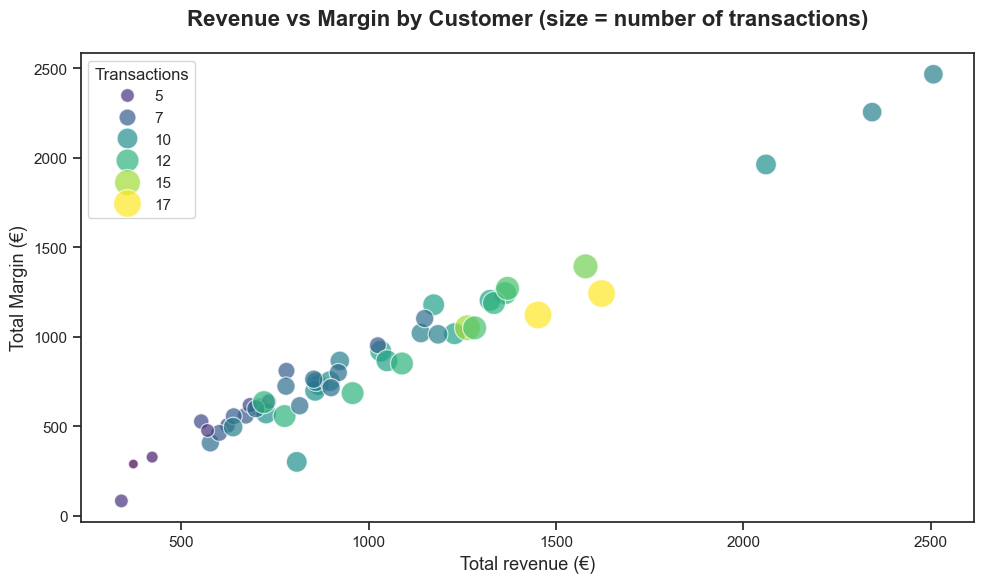

In [28]:
# --------------------- Revenue vs Margin Scatter Plot by Customer ---------------------
client_summary = sales_gender.groupby("CustomerID", observed=True).agg(
    Revenue_total=("Revenue","sum"),
    Margin_total=("Margin","sum"),
    Transactions=("TransactionID","count")
).reset_index()

plt.figure(figsize=(10,6))
sns.scatterplot(
    data=client_summary,
    x="Revenue_total",
    y="Margin_total",
    size="Transactions",
    hue="Transactions",
    palette="viridis",
    sizes=(50, 400),
    alpha=0.7
)
plt.title(
    "Revenue vs Margin by Customer (size = number of transactions)",
    fontsize=16,
    weight="bold",
    pad=20
)
plt.xlabel("Total revenue (€)", fontsize=13)
plt.ylabel("Total Margin (€)", fontsize=13)
plt.tight_layout()
plt.show()

- There is a clear **positive correlation**: customers generating higher revenue are also the most profitable.  
- High transaction volumes concentrate most of the margin.

### 15.7 Average Revenue by Day of Week <a id="157-average-revenue-by-day-of-week"></a>  
- Analyze revenue variations across days of the week to optimize operations and promotional strategies.

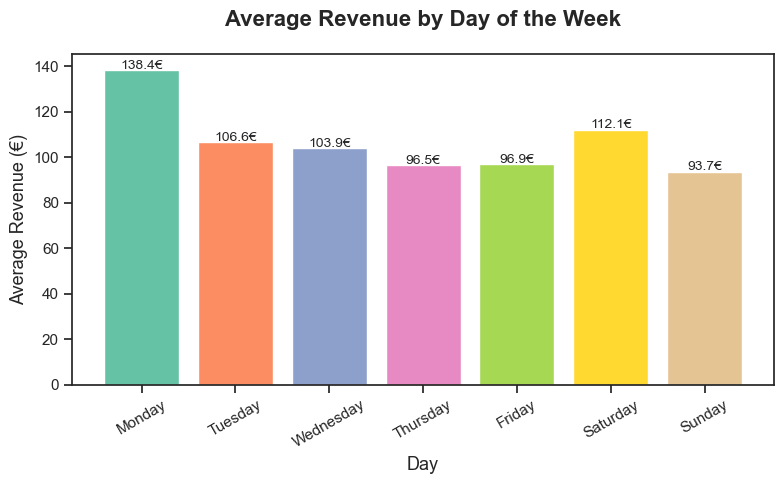

In [29]:
# --------------------- Average Revenue by Day of the Week ---------------------
weekday_rev = sales_clean.groupby("Weekday", observed=True)["Revenue"].mean().reindex(
    ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
)

plt.figure(figsize=(8,5))
plt.bar(weekday_rev.index, weekday_rev.values, color=sns.color_palette("Set2", len(weekday_rev)))
plt.title("Average Revenue by Day of the Week", fontsize=16, weight="bold", pad=20)
plt.xlabel("Day", fontsize=13)
plt.ylabel("Average Revenue (€)", fontsize=13)
plt.xticks(rotation=30)
for i, v in enumerate(weekday_rev.values):
    plt.text(i, v + 0.5, f"{v:.1f}€", ha='center', fontsize=10)
plt.tight_layout()
plt.show()

- **Monday** and **Saturday** perform best, while Sunday is the weakest day.  
- Activity remains overall stable throughout the week, with identifiable peaks that can be leveraged to optimize **stock management and promotional planning**.

## 16. Customer Value Segmentation & Revenue Concentration Analysis <a id="16-customer-lifetime-value--pareto-analysis"></a> 

### 16.1.1 Customer Lifetime Value (CLV) <a id="1611-customer-lifetime-value-clv"></a> 
- Analyze total revenue, margin, and number of transactions per customer to identify the most valuable customers.
- Helps identify high-value customers (high revenue and margin).  
- Serves as a basis for strategic analyses such as customer segmentation or loyalty programs.

In [30]:
# --------------------- Customer Metrics Analysis ---------------------
clv = sales_clean.groupby("CustomerID").agg(
    total_revenue=("Revenue", "sum"),
    total_margin=("Margin", "sum"),
    transactions=("TransactionID", "count"),
    avg_transaction_value=("Revenue", "mean")
).reset_index()

clv.head().round(2)

,CustomerID,total_revenue,total_margin,transactions,avg_transaction_value
0,1,866.92,730.35,10,86.69
1,2,496.21,434.17,3,165.40
2,3,1229.44,1017.06,11,111.77
3,4,1007.92,854.05,12,83.99
4,5,584.60,463.41,8,73.08


- Customers exhibit different profiles : some generate **a high number of transactions with moderate average revenue** (e.g., CustomerID 4), while others have **fewer transactions but very high profitability** (e.g., CustomerID 2).  
- This insight is crucial for customer segmentation and for prioritizing loyalty and promotional strategies.  
- Margin generally follows revenue, confirming that the most active customers are also the most profitable.

### 16.1.2 Customer Revenue Distribution <a id="1612-customer-revenue-distribution"></a> 
- Visualize the distribution of revenue generated by customers to identify major contributors.

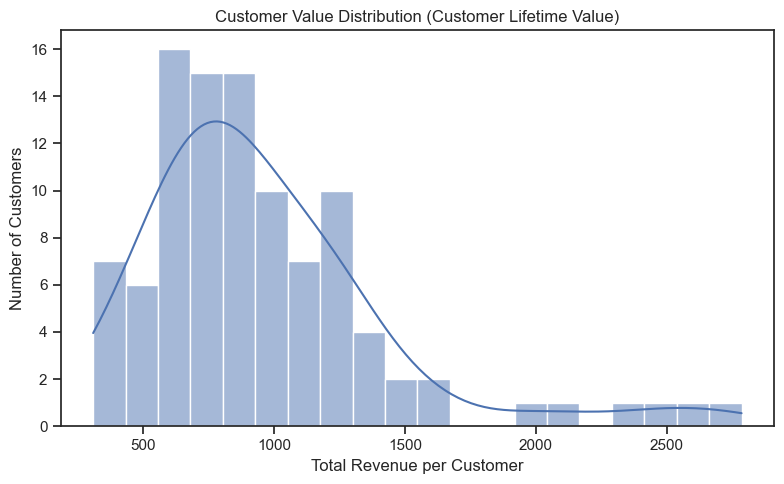

In [31]:
# --------------------- Distribution of Total Revenue per Customer ---------------------
plt.figure(figsize=(8,5))
sns.histplot(clv["total_revenue"], bins=20, kde=True)
plt.title("Customer Value Distribution (Customer Lifetime Value)")
plt.xlabel("Total Revenue per Customer")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.show()

- **Customer Lifetime Value (CLV)** represents the total revenue generated by each customer.  
- The distribution shows that most customers generate revenue between **600 and 1200**, while a small group exceeds **2000**, resulting in a right-skewed distribution.  
- This indicates that a **small proportion of customers contributes significantly to total revenue**, highlighting the importance of targeted retention strategies for high-value customers.

### 16.2 Pareto Analysis – Product Revenue Contribution <a id="163-pareto-analysis--product-revenue-contribution"></a> 
- Apply the Pareto principle to identify the products generating the majority of revenue.

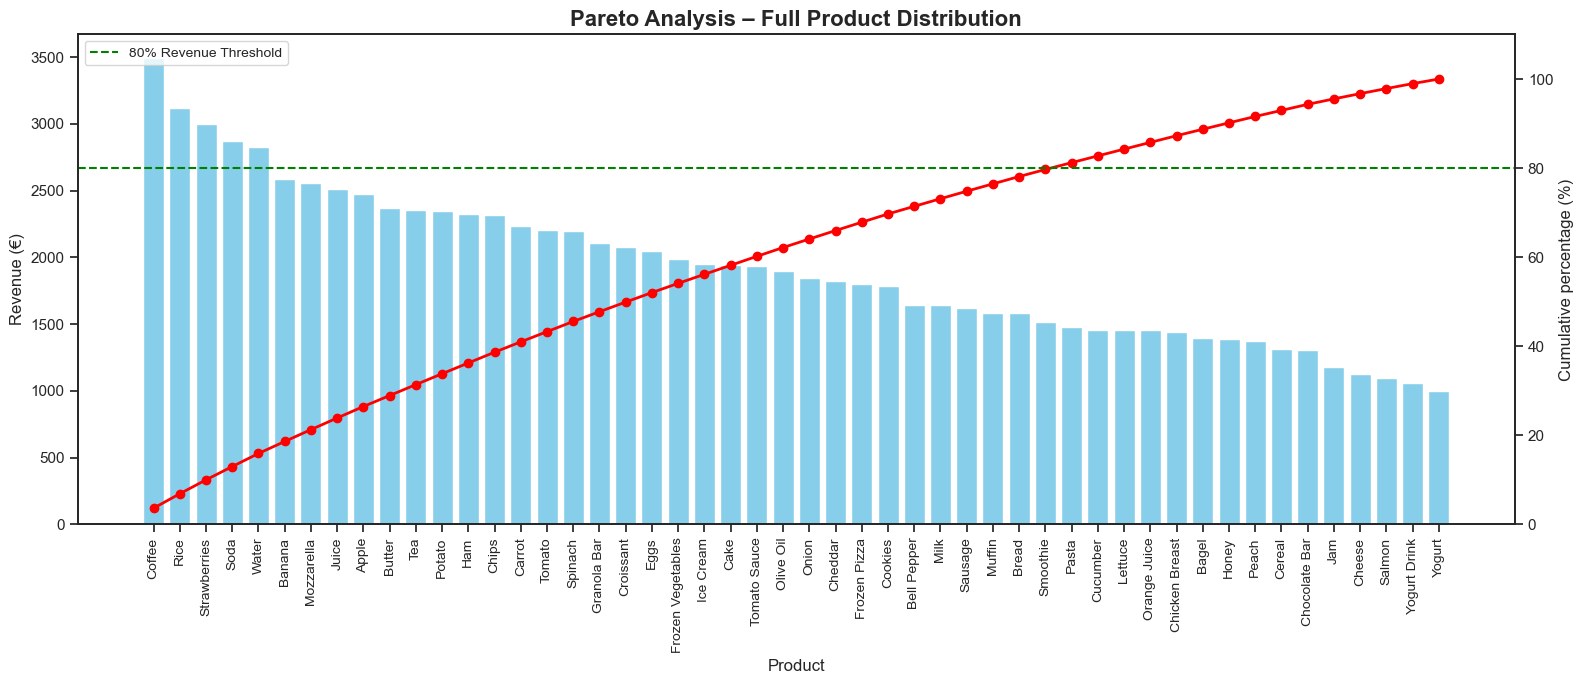

In [32]:
# --------------------- Total revenue by product   ---------------------
product_revenue = sales_products.groupby("ProductName")["Revenue"].sum().reset_index()
product_revenue = product_revenue.sort_values(by="Revenue", ascending=False).reset_index(drop=True)

# Cumulative values and cumulative percentage
product_revenue["cumulative_revenue"] = product_revenue["Revenue"].cumsum()
total_revenue = product_revenue["Revenue"].sum()
product_revenue["cumulative_percentage"] = 100 * product_revenue["cumulative_revenue"] / total_revenue

# Pareto chart 
labels = product_revenue["ProductName"].tolist()
fig, ax = plt.subplots(figsize=(16,7))

# Bars for all products
ax.bar(product_revenue["ProductName"], product_revenue["Revenue"], color='skyblue', label='Revenue by Product')

# Cumulative line
ax2 = ax.twinx()
ax2.plot(product_revenue["ProductName"], product_revenue["cumulative_percentage"], color='red', marker='o', linewidth=2)
ax2.set_ylabel("Cumulative percentage (%)", fontsize=12)
ax2.set_ylim(0, 110)

# 80% reference line 
ax2.axhline(80, color='green', linestyle='--', label='80% Revenue Threshold')
ax2.legend(loc='upper left', fontsize=10)

# Axes
ax.set_xticks(range(len(labels)))
ax.set_xticklabels(labels, rotation=90, fontsize=10)
ax.set_ylabel("Revenue (€)", fontsize=12)
ax.set_xlabel("Product", fontsize=12)
plt.title("Pareto Analysis – Full Product Distribution", fontsize=16, weight="bold")
plt.tight_layout()
plt.show()

- This analysis applies the **Pareto principle** to assess product contributions to total revenue.  
- The results show that **80% of total revenue is generated by approximately 70% of products**, indicating a **moderately concentrated revenue distribution across the catalog rather than a strong concentration on a few items**.    
- This suggests a **low dependency on a small number of products** and highlights opportunities to optimize **pricing, promotions, and product highlighting strategies**.

## 17. Cleaned Datasets Export <a id="17-cleaned-datasets-export"></a> 
- Save cleaned datasets for future analysis or sharing with other teams.

In [33]:
# --- Cleaned CSV export ---
sales_clean.to_csv("sales_clean.csv", index=False)
customers_clean.to_csv("customers_clean.csv", index=False)
products_clean.to_csv("products_clean.csv", index=False)

print("All cleaned datasets have been successfully exported as CSV files.")

All cleaned datasets have been successfully exported as CSV files.


- The exported files now contain only reliable data, with no critical missing values for Revenue or Profit.  
- Ready for further analysis or integration into an enterprise data pipeline.

## 18. Executive Conclusion <a id="18-executive-conclusion"></a> 

This project aimed to analyze product sales and profitability for **Eurofood Corp** in order to identify key drivers for optimizing **revenue** and **margin**, based on a consolidated dataset of **1,000 transactions, 100 customers, and 50 products**.

---

## Key Insights

### Customer Segment Performance

| Segment      | Revenue     | Profit   | Interpretation |
|--------------|-------------|----------|----------------|
| Members      | ~€52K       | ~€7.4K   | Stable and consistent loyalty behavior |
| Non-Members  | ~€44K       | ~€7.6K   | More volatile, with seasonal peaks |

---

### Customer Distribution

| Metric | Value |
|--------|-------|
| Average customer revenue | €600 – €1,200 |
| Top customers | > €2,000 |

- Strong heterogeneity in revenue contribution across customers

---

### Overall Performance

| Metric | Value |
|--------|-------|
| Total revenue | ~€96K |
| Total profit | ~€15K |

---

### Revenue Structure

- **Moderate sales concentration** (non-extreme Pareto effect)  
- **Relatively diffuse distribution** across products  
- **Low dependency on a small number of SKUs**, without critical concentration

---

## Business Implications

- **Members represent a key strategic segment**, driving stable revenue streams  
- **Non-Members represent a growth opportunity through targeted marketing activation**  
- Opportunity to increase **average customer value in mid-tier segments**  
- Need to secure **top-selling products while diversifying the product portfolio**  
- Importance of continuous **KPI monitoring through dashboards (revenue, margin, frequency)**  

---

## Estimated Business Impact

| Action | Estimated Impact |
|--------|------------------|
| +10% Members growth | Potential revenue increase (assuming stable behavior) |
| Non-Member conversion | Improved revenue stability and reduced volatility |
| Segment optimization | +€5K to €10K potential uplift |

---

## Limitations

These results should be interpreted as **directional insights**, based on historical data.

They could be enhanced with:
- sales channels data
- marketing and promotional information
- customer behavioral variables

---

## Final Conclusion

This analysis provides a clear answer to the initial business problem by highlighting the main performance drivers:

- **Customer segmentation as a key revenue driver**
- **Product structure and sales distribution**
- **Revenue concentration dynamics**

This supports the shift from **descriptive sales reporting** toward a more **analytical, decision-driven approach** centered on **performance management, revenue optimization, and customer value creation**.